# Control plots for measurements on BGS mocks

> Note : We are not using the Observable class here, as we want to visualize the measurements as they are done - even incomplet, and the compression methods will crash if all the data is not present.

## 0- Setup

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from acm.utils.default import cosmo_list
from acm.utils.abacus import get_abacus_phases
from plot_utils import load_hod_params, plot_parameters_histogram, plot_parameters_triangle

In [2]:
parameters_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/parameters/')
measurements_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/measurements/')
dr2_dir = Path('/pscratch/sd/s/sbouchar/DR2_BGS/measurements/')
sg_dir = Path('/pscratch/sd/s/sbouchar/SecondGen/CubicBox/BGS/z0.200/AbacusSummit_base_c000_ph000/measurements/Mr-20') # SecondGen measurements directory
bgs_nofilter_dir = Path('/pscratch/sd/s/sbouchar/test/bgs_nofilter/base/c000_ph000/seed0/') # Temporary, to test density filtering

abacus_dir = Path('/global/cfs/cdirs/desi/cosmosim/Abacus/small/')

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.show()

## 1- Parameter sampling

### 1.1- Cosmological parameters
See [AbacusSummit](https://abacussummit.readthedocs.io/en/latest/cosmologies.html) cosmologies for details.

### 1.2- HOD parameters

#### Compare sampling for BGS and EMC

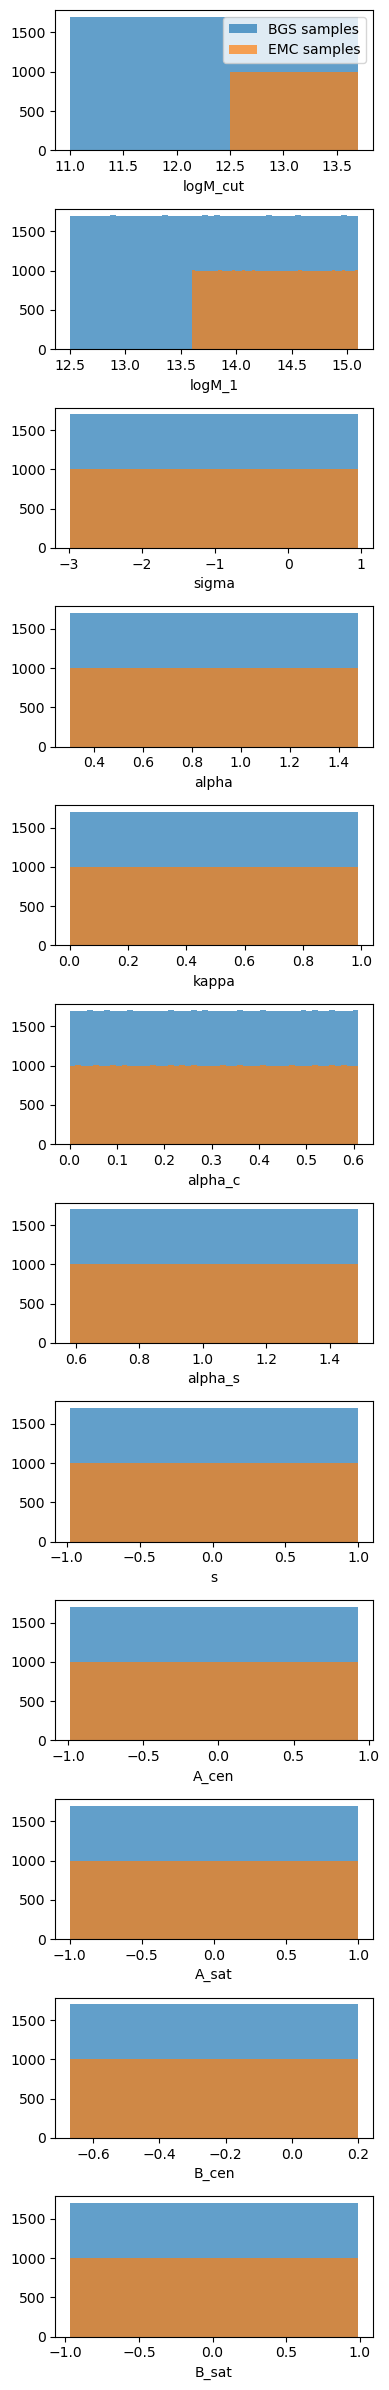

In [4]:
hod_params_bgs = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_bgs = np.concatenate([hod_params_bgs[key] for key in sorted(hod_params_bgs.keys())])

hod_params_emc = load_hod_params('/pscratch/sd/e/epaillas/emc/hod_params/yuan23/cosmo_split/')
hod_params_emc = np.concatenate([hod_params_emc[key] for key in sorted(hod_params_emc.keys())])

fig, ax = plot_parameters_histogram(
    parameters = [hod_params_bgs, hod_params_emc], 
    names = hod_params_bgs.dtype.names, 
    labels = ['BGS samples', 'EMC samples'], 
    bins = 50, 
    alpha = 0.7, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

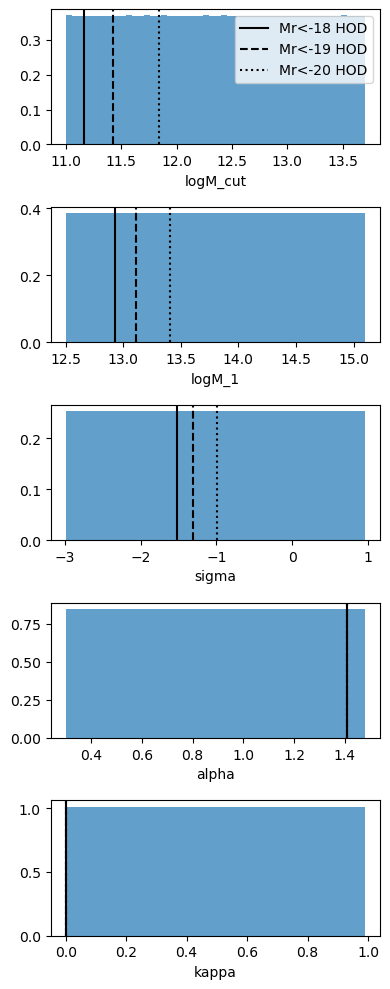

In [5]:
hod_params_bgs = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_bgs = np.concatenate([hod_params_bgs[key] for key in sorted(hod_params_bgs.keys())])

params = ['logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa']
fig, ax = plot_parameters_histogram(
    parameters = [hod_params_bgs,], 
    names = params, 
    labels = ['BGS samples'], 
    bins = 50, 
    alpha = 0.7, 
    density = True,
)

HOD_params = dict(
    Mr18 = dict(
        logM_cut = 11.16745, 
        logM_1 = 12.92566, 
        kappa = 10**(5.08046 - 11.16745),  # kappa = M0/Mcut = 10^(logM0 - logMcut)
        sigma = np.log10(0.02969), 
        alpha = 1.40723
    ),
    Mr19 = dict(
        logM_cut = 11.42954, 
        logM_1 = 13.10684, 
        kappa = 10**(7.16418 - 11.42954), # kappa = M0/Mcut = 10^(logM0 - logMcut)
        sigma = np.log10(0.04897), 
        alpha = 1.40762,
    ),
    Mr20 = dict(
        logM_cut = 11.84549, 
        logM_1 = 13.40267, 
        kappa = 10**(9.24791-11.84549), # kappa = M0/Mcut = 10^(logM0 - logMcut) 
        sigma = np.log10(0.10304), # Passing logsigma to BoxHOD 
        alpha = 1.41008
    )
)

ls = ['-', '--', ':']
for i, Mr in enumerate([-18, -19, -20]):
    for j, key in enumerate(params):
        ax[j].axvline(HOD_params[f'Mr{abs(Mr)}'][key], color='k', linestyle=ls[i])

handles = []
for i, Mr in enumerate([-18, -19, -20]):
    handle = plt.Line2D([], [], color='k', linestyle=ls[i], label=f'Mr<{Mr} HOD')
    handles.append(handle)

ax[0].legend(handles=handles)
fig.tight_layout()

#### Compare cosmologies for BGS

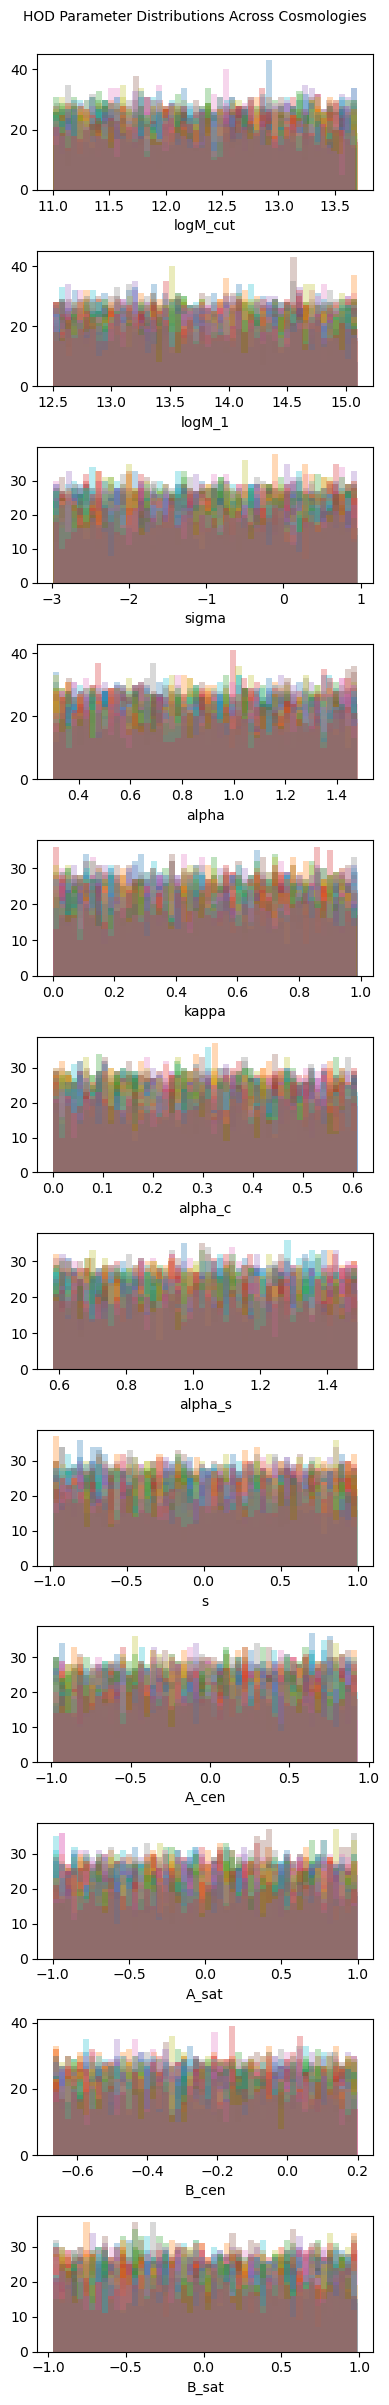

In [6]:
hod_params_cosmo = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_cosmo = [hod_params_cosmo[f'Bouchard25_c{c:03d}'] for c in sorted(cosmo_list)]

fig, ax = plot_parameters_histogram(
    parameters = hod_params_cosmo, 
    names = hod_params_cosmo[0].dtype.names, 
    labels = [f'c{c:03d}' for c in sorted(cosmo_list)],
    bins = 50, 
    alpha = 0.3, 
    # density = True,
)
# ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title='Cosmology')
fig.suptitle('HOD Parameter Distributions Across Cosmologies', fontsize=10, y=1.00)
fig.tight_layout()

#### Check Cosmological parameters

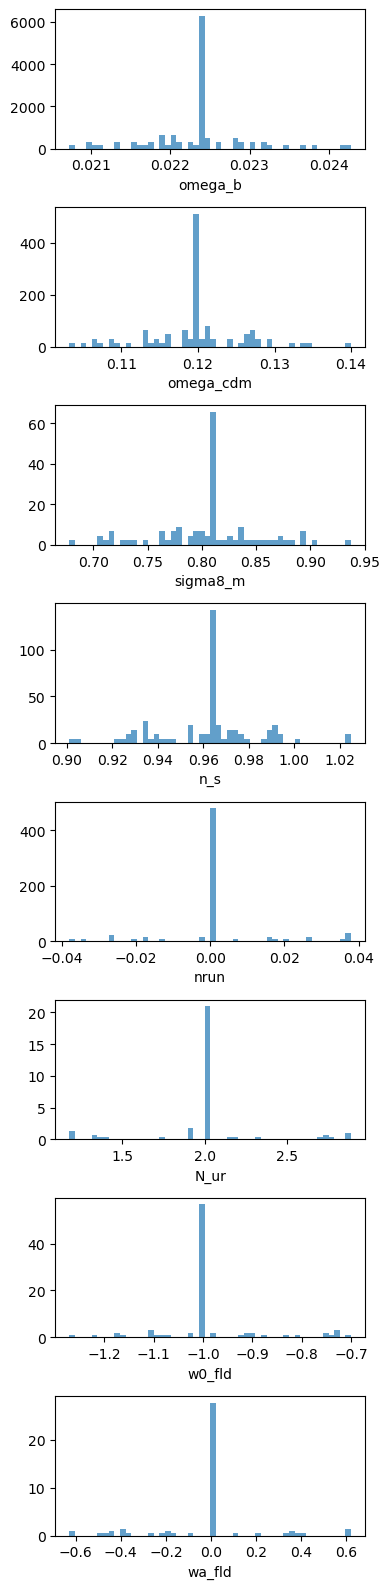

In [7]:
cosmo_params = load_hod_params(str(parameters_dir / 'cosmo+hod_params'))
cosmo_params = np.concatenate([cosmo_params[key] for key in sorted(cosmo_params.keys())])

fig, ax = plot_parameters_histogram(
    parameters = [cosmo_params], 
    names = cosmo_params.dtype.names[:8], 
    bins = 50, 
    alpha = 0.7, 
    density = True
)
fig.tight_layout()

#### Plot all c000 HOD parameters vs HOD parameters returning nbar=0.0085 for c000

Imposing a physical constraint on the sampled HOD space through a density cut.

**First measuring the density for all sampled HODs for c000.**

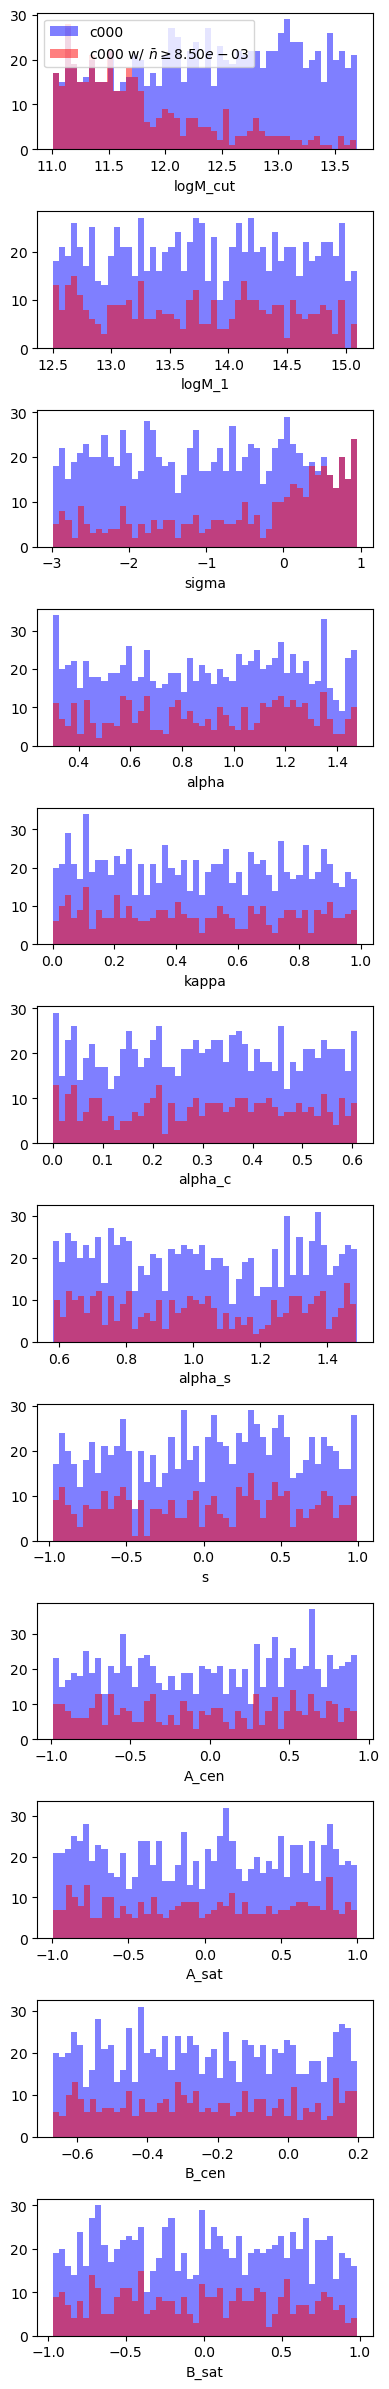

In [98]:
density_dir = bgs_nofilter_dir
density_fns = sorted(density_dir.glob('hod*/density.npy'))
densities = [np.load(fn) for fn in density_fns]
target_density = 8.5e-3 # Mpc^-3 h^3
density_idx = [int(fn.stem.lstrip('hod')) for i, fn in enumerate(sorted(density_dir.glob('hod*'))) if densities[i] >= target_density]

keys = [f'c{c:03d}' for c in sorted(cosmo_list)]
hod_params_c000 = load_hod_params(parameters_dir / 'hod_params', keys=keys)['c000']
hod_params_density = hod_params_c000[density_idx]

fig, ax = plot_parameters_histogram(
    parameters = [hod_params_c000, hod_params_density], 
    names = hod_params_c000.dtype.names, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

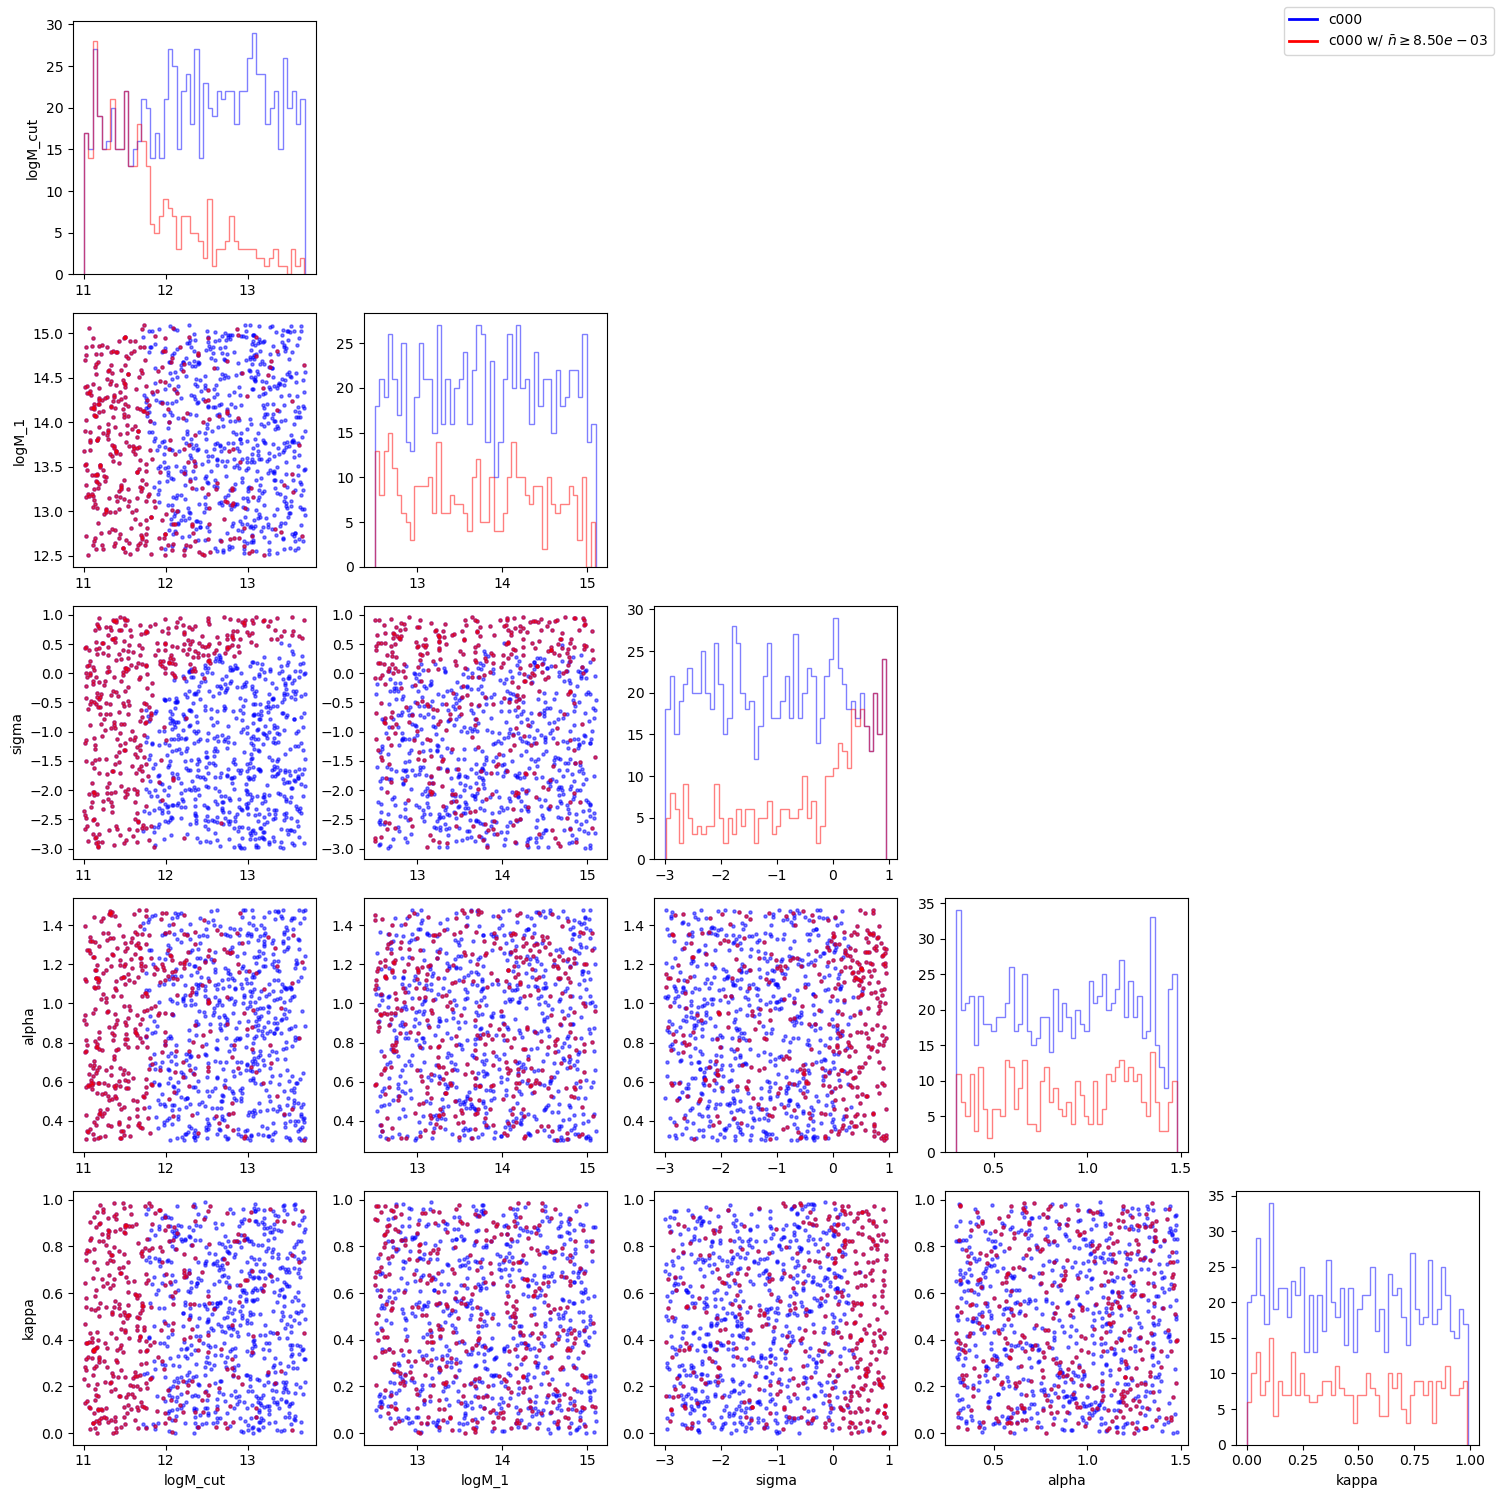

In [99]:
# triangle version
params = ['logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa']

fig, ax = plot_parameters_triangle(
    parameters = [hod_params_c000, hod_params_density], 
    names = params, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    s = 5,
)
fig.tight_layout()

**Then, the HOD space for the first 100 HOD reaching the target density of 0.0085 (Mpc/h)^-3 is selected for all cosmologies.** 

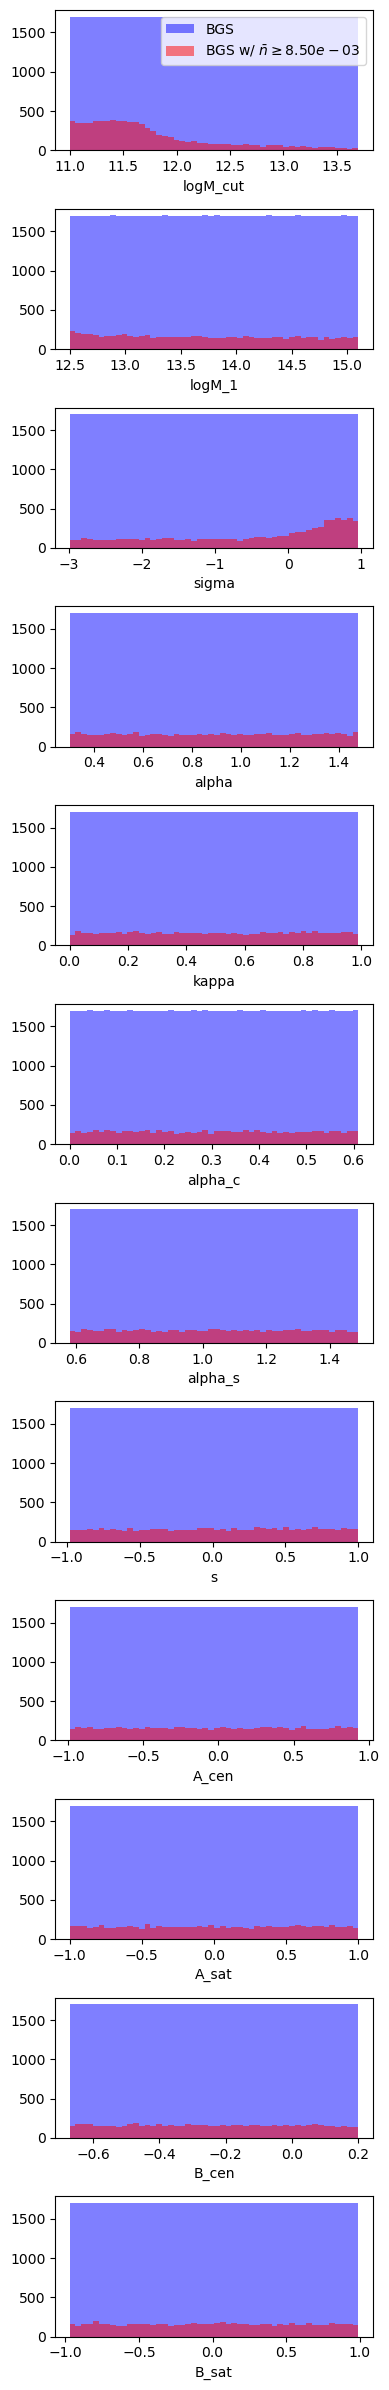

In [100]:
target_density = 8.5e-3 # Mpc^-3 h^3

keys = [f'c{c:03d}' for c in sorted(cosmo_list)]
hod_params_dict = load_hod_params(parameters_dir / 'hod_params', keys=keys)
hod_params_density = []
hod_params_bgs = []

for c in cosmo_list:
    hod_fns = sorted(measurements_dir.glob(f'base/c{c:03d}_ph000/seed0/hod*'))
    density_idx = [int(fn.stem.lstrip('hod')) for fn in hod_fns]
    
    if len(density_idx) == 0:
        continue

    hod_params_c = hod_params_dict[f'c{c:03d}'][density_idx]
    hod_params_density.append(hod_params_c)
    hod_params_bgs.append(hod_params_dict[f'c{c:03d}'])

hod_params_density = np.concatenate(hod_params_density) # HOD parameters across cosmologies with density cut
hod_params_bgs = np.concatenate(hod_params_bgs) # HOD parameters across all cosmologies

fig, ax = plot_parameters_histogram(
    parameters = [hod_params_bgs, hod_params_density], 
    names = hod_params_bgs.dtype.names, 
    labels = ['BGS', rf'BGS w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

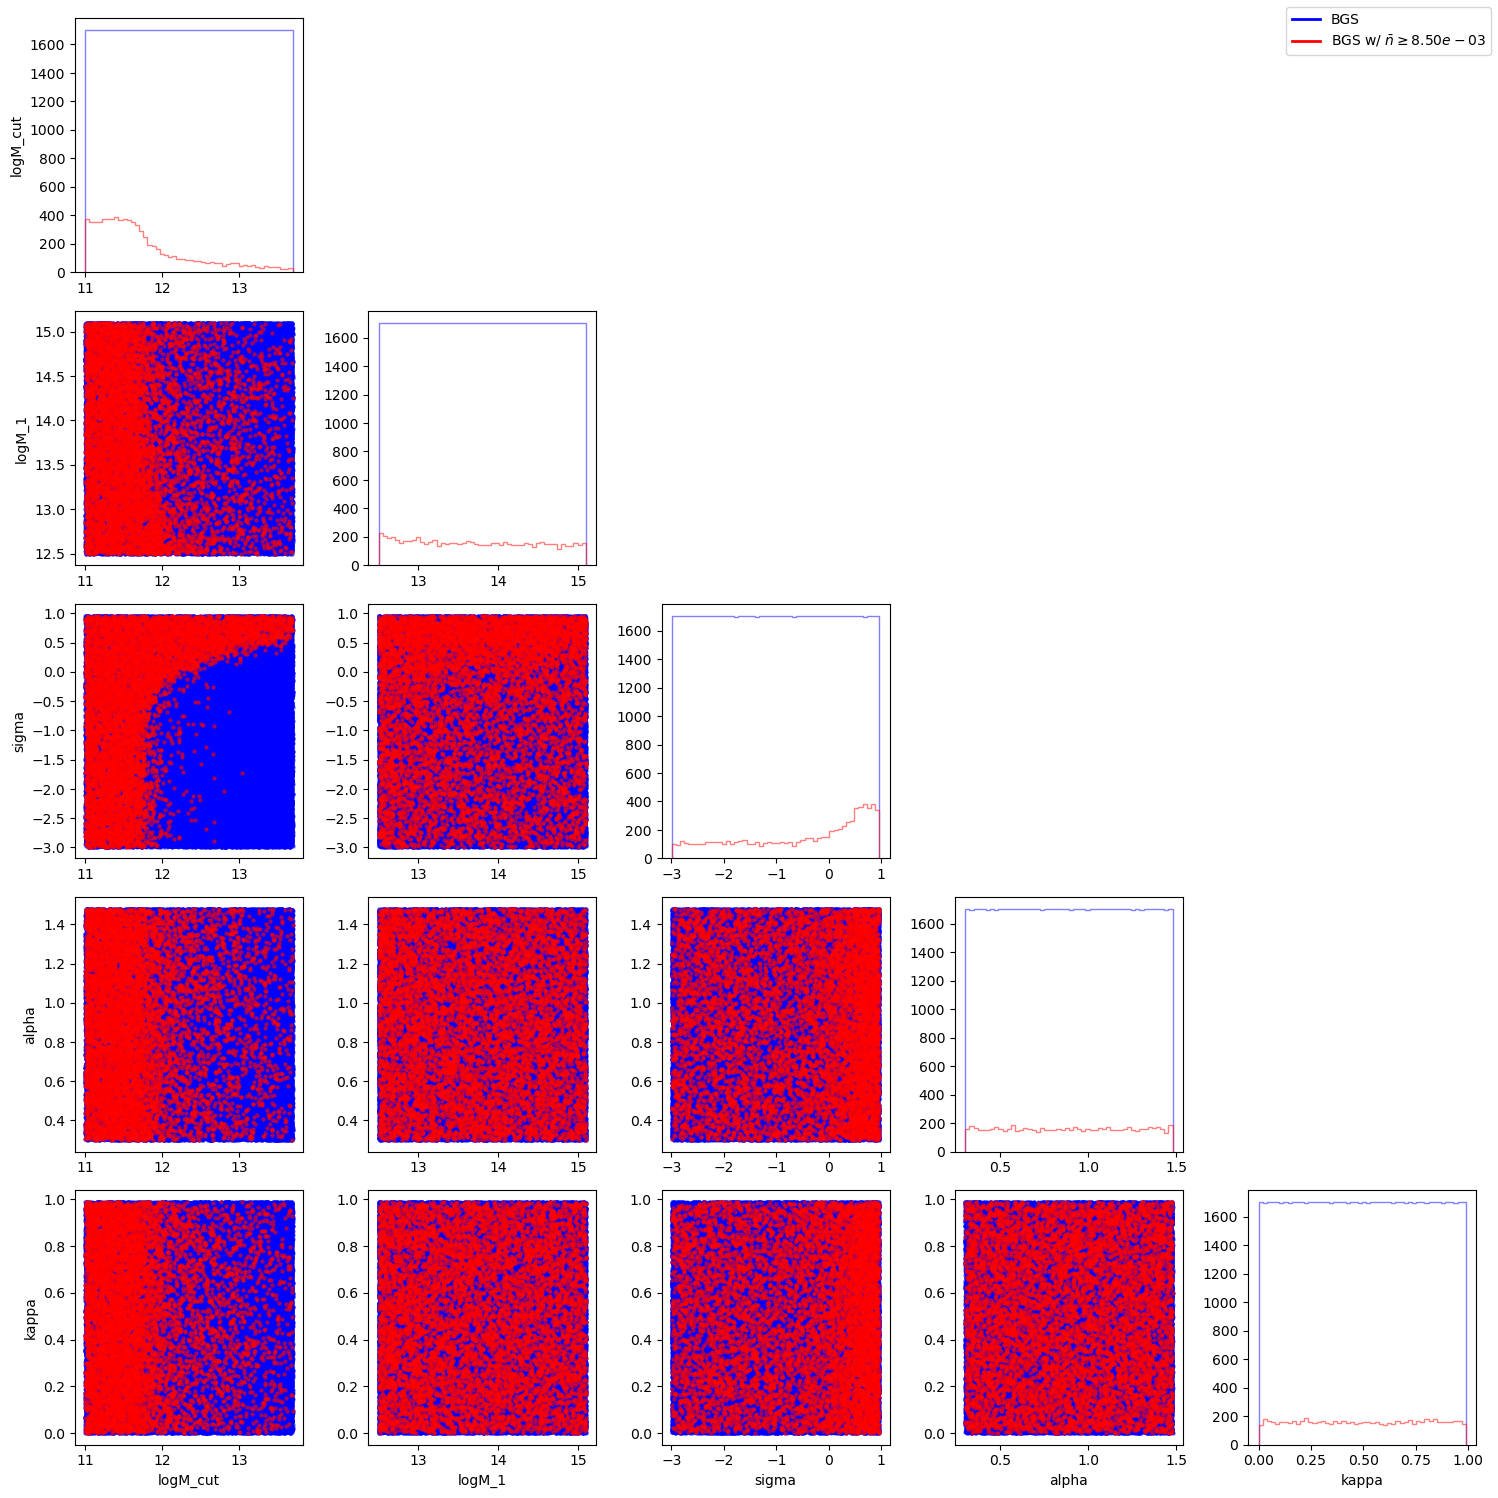

In [101]:
# triangle version
params = ['logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa']

fig, ax = plot_parameters_triangle(
    parameters = [hod_params_bgs, hod_params_density], 
    names = params, 
    labels = ['BGS', rf'BGS w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    s = 5,
)
fig.tight_layout()

## 2- Processed mocks

Count the number of HOD folders in each cosmology folder.

Then, count the number of statistic files computed (marginalized over HOD) for each cosmology.

In [4]:
def get_hod_folders(dir: Path, cosmologies: list[int], phases: list[int], seeds: list[int], sim_type: str) -> dict:
    hod_fns = {}
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                f = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                fn_list = sorted(f.glob('hod*'))
                hod_fns[(cosmology, phase, seed)] = fn_list
    return hod_fns

#### Base boxes hod counts

In [5]:
hod_fns = get_hod_folders(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

expected_number = 100
warn_empty = True
print_full = False

for cosmology in cosmo_list:
    count = len(hod_fns[(cosmology, 0, 0)])
    last_hod = hod_fns[(cosmology, 0, 0)][-1].stem.lstrip('hod')
    if count == expected_number and print_full:
        print(f'Cosmology c{cosmology:03d} has {count} HOD folders. Last HOD: {last_hod}')
    elif count < expected_number and count > 0:
        print(f'Cosmology c{cosmology:03d} has {count} HOD folders (expected {expected_number}). Last HOD: {last_hod}')
    elif count == 0 and warn_empty:
        print(f'Cosmology c{cosmology:03d} has no HOD folders.')

Cosmology c152 has 4 HOD folders (expected 100). Last HOD: 005
Cosmology c153 has 67 HOD folders (expected 100). Last HOD: 146
Cosmology c155 has 1 HOD folders (expected 100). Last HOD: 002
Cosmology c159 has 1 HOD folders (expected 100). Last HOD: 000
Cosmology c179 has 1 HOD folders (expected 100). Last HOD: 000
Cosmology c181 has 1 HOD folders (expected 100). Last HOD: 002


In [72]:
statistics = [
    'density',
    'tpcf_los_x',
    'tpcf_los_y',
    'tpcf_los_z',
    'quantile_data_correlation_los_x',
    'quantile_data_correlation_los_y',
    'quantile_data_correlation_los_z',
    'quantile_correlation_los_x',
    'quantile_correlation_los_y',
    'quantile_correlation_los_z',
]
expected_number = 100
warn_empty = True
print_full = False

stat_count = {statistic: {} for statistic in statistics}

for cosmology in cosmo_list:
    for statistic in statistics:
        count = 0
        for fn in hod_fns[(cosmology, 0, 0)]:
                stat_fns = sorted(fn.glob(f'{statistic}*.npy'))
                count += len(stat_fns)
        
        stat_count[statistic][cosmology] = count
        if count == expected_number and print_full:
            print(f'Cosmology c{cosmology:03d} has {count} {statistic} files.')
        elif count < expected_number and count > 0:
            print(f'Cosmology c{cosmology:03d} has {count} {statistic} files (expected {expected_number}).')
        elif count == 0 and warn_empty:
            print(f'Cosmology c{cosmology:03d} has no {statistic} files.')

Cosmology c152 has 4 density files (expected 100).
Cosmology c152 has 3 tpcf_los_x files (expected 100).
Cosmology c152 has 3 tpcf_los_y files (expected 100).
Cosmology c152 has 3 tpcf_los_z files (expected 100).
Cosmology c152 has no quantile_data_correlation_los_x files.
Cosmology c152 has no quantile_data_correlation_los_y files.
Cosmology c152 has no quantile_data_correlation_los_z files.
Cosmology c152 has no quantile_correlation_los_x files.
Cosmology c152 has no quantile_correlation_los_y files.
Cosmology c152 has no quantile_correlation_los_z files.
Cosmology c153 has 49 density files (expected 100).
Cosmology c153 has 48 tpcf_los_x files (expected 100).
Cosmology c153 has 48 tpcf_los_y files (expected 100).
Cosmology c153 has 48 tpcf_los_z files (expected 100).
Cosmology c153 has 48 quantile_data_correlation_los_x files (expected 100).
Cosmology c153 has 48 quantile_data_correlation_los_y files (expected 100).
Cosmology c153 has 48 quantile_data_correlation_los_z files (expect

## 3- Base boxes measurements

### 3.1- Density

In [105]:
def get_densities(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get densities from all the HOD realizations."""
    densities = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                fn_list = (Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}').glob('hod*/density.npy')
                for fn in fn_list:
                    d = np.load(fn, allow_pickle=True).item()
                    densities.append(d)
    densities = np.array(densities)
    return densities

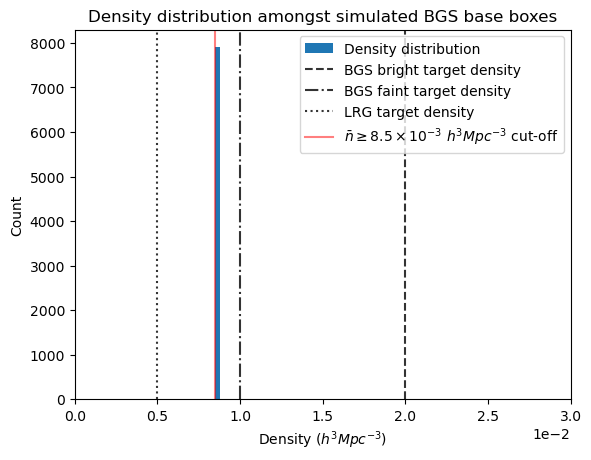

In [106]:
densities = get_densities(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

bins = np.linspace(0, 0.03, 100)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.5, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS base boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

### 3.2- Two-point correlation function

In [11]:
from pycorr import TwoPointEstimator
def get_tpcf(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get two-point correlation functions from all the HOD realizations."""
    tpcfs = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                dir_ = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                # Get all the HOD realizations
                hod_folders = sorted(dir_.glob('hod*'))
                for hod in hod_folders:
                    fn_list = sorted(hod.glob('tpcf_los_*.npy'))
                    cf_list = [TwoPointEstimator.load(fn).normalize() for fn in fn_list]
                    cf = sum(cf_list)
                    if len(cf_list) > 0:
                        tpcfs.append(cf)
    tpcfs = np.array(tpcfs)
    return tpcfs

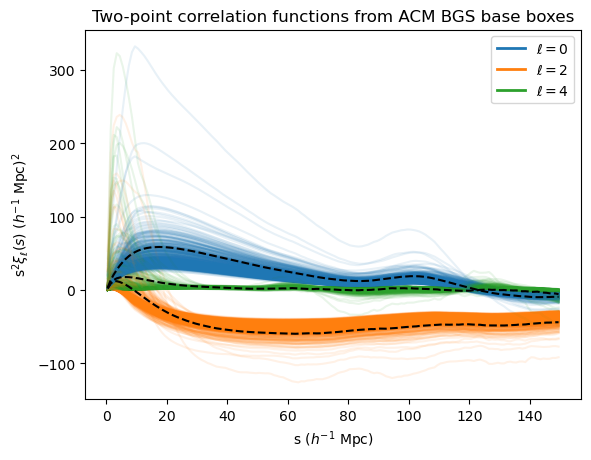

In [ ]:
cfs = get_tpcf(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

ells = [0, 2, 4]
for cf in cfs:
    s, poles = cf(ells=ells, return_sep=True)
    for i, p in enumerate(ells):
            plt.plot(s, poles[i]*s**2, alpha=0.1, c=f'C{i}')

handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=rf'$\ell={{{i*2}}}$') for i in range(3)
]
plt.legend(handles=handles)

plt.xlabel(r's ($h^{-1}$ Mpc)')
plt.ylabel(r's$^2 \xi_{\ell}(s)$ ($h^{-1}$ Mpc)$^2$')
plt.title('Two-point correlation functions from ACM BGS base boxes');

fns = sorted(sg_dir.glob('tpcf_los_*.npy'))
sg_cf = sum([TwoPointEstimator.load(fn).normalize() for fn in fns])

s, poles = sg_cf(ells=ells, return_sep=True)
for i, p in enumerate(ells):
    plt.plot(s, poles[i]*s**2, alpha=1.0, c=f'k', ls='--')
    
# plt.ylim(-100, 100);
# plt.xlim(0, 30);

### 3.3- Density split

In [6]:
def get_ds_cf(stat_name: str, dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str, quantiles: list = [0,1,3,4]) -> np.ndarray:
    """Get DensitySplit correlation functions from all the HOD realizations."""
    ds_cfs = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                dir_ = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                # Get all the HOD realizations
                hod_folders = sorted(dir_.glob('hod*'))
                for hod in hod_folders:
                    fn_list = sorted(hod.glob(f'{stat_name}_los_*.npy'))
                    cf_list = []
                    for q in quantiles:
                        cfs = [np.load(fn, allow_pickle=True)[q].normalize() for fn in fn_list]
                        cf = sum(cfs)
                        cf_list.append(cf)
                    if len(cf_list) > 0:
                        ds_cfs.append(cf_list)
    ds_cfs = np.array(ds_cfs)
    return ds_cfs

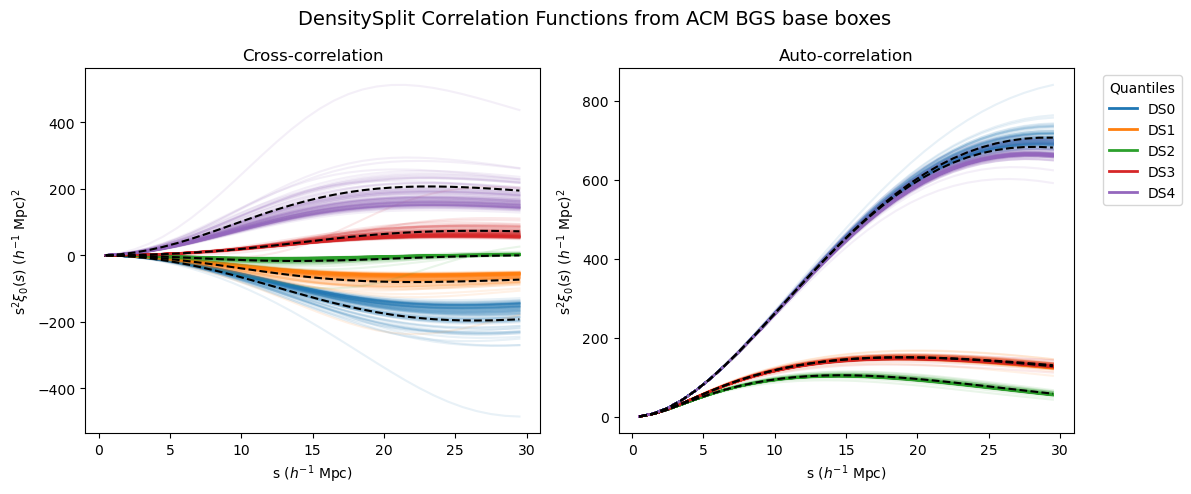

In [ ]:
quantiles = [0, 1, 2, 3, 4] 
cc_cfs = get_ds_cf(stat_name='quantile_data_correlation', dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base', quantiles=quantiles)
ac_cfs = get_ds_cf(stat_name='quantile_correlation', dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base', quantiles=quantiles)

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)

ell = 0
for i, q in enumerate(quantiles):
    for cf in cc_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[0].plot(s, poles[0]*s**2, alpha=0.1, c=f'C{i}')
    for cf in ac_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[1].plot(s, poles[0]*s**2, alpha=0.1, c=f'C{i}')
        
handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=f'DS{q}') for i, q in enumerate(quantiles)
]
ax[1].legend(handles=handles, title='Quantiles', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[0].set_title('Cross-correlation')
ax[1].set_title('Auto-correlation')

for a in ax:
    a.set_xlabel(r's ($h^{-1}$ Mpc)')
    a.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')

fig.suptitle('DensitySplit Correlation Functions from ACM BGS base boxes', fontsize=14)
fig.tight_layout()

fn_list_cc = sorted(sg_dir.glob('quantile_data_correlation_los_*.npy'))
fn_list_ac = sorted(sg_dir.glob('quantile_correlation_los_*.npy'))
ccf = [sum([np.load(fn, allow_pickle=True)[q].normalize() for fn in fn_list_cc]) for q in quantiles]
acf = [sum([np.load(fn, allow_pickle=True)[q].normalize() for fn in fn_list_ac]) for q in quantiles]

for i, q in enumerate(quantiles):
    s, poles = ccf[i](ells=[ell], return_sep=True)
    ax[0].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

    s, poles = acf[i](ells=[ell], return_sep=True)
    ax[1].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

### 3.4- Interactive visualization of the measurements

In [ ]:
from matplotlib.widgets import Button, Slider
%matplotlib widget

ells = [0]

hod_idx_fns = get_hod_folders(dir=measurements_dir, cosmologies=[0], phases=[0], seeds=[0], sim_type='base')
hod_idx = [int(f.stem.split('hod')[-1]) for f in hod_idx_fns[(0,0,0)]]
cfs = get_tpcf(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.25)

s, poles = cfs[0](ells=ells, return_sep=True)
line = ax.plot(s, poles[0]*s**2, alpha=1.0, c='k')
ax.set_xlabel(r's ($h^{-1}$ Mpc)')
ax.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')
ax.set_title(f'Two-point correlation function for HOD {hod_idx[0]}');

slider_ax = fig.add_axes([0.25, 0.1, 0.65, 0.03])
hod_slider = Slider(
    ax=slider_ax,
    label='HOD Index',
    valmin=hod_idx[0],
    valmax=hod_idx[-1],
    valinit=hod_idx[0],
    valstep=1,
    orientation='horizontal'
)

def plot_hod(idx: int):
    idx = int(idx)
    if idx not in hod_idx:
        return
    idx = hod_idx.index(idx)
    hod = hod_idx[idx]
    s, poles = cfs[idx](ells=ells, return_sep=True)
    line[0].set_ydata(poles[0]*s**2)
    ax.relim()
    ax.autoscale_view()
    ax.set_title(f'Two-point correlation function for HOD {hod}')
    fig.canvas.draw_idle()

hod_slider.on_changed(plot_hod)
resetax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', hovercolor='0.975')
def reset(event):
    hod_slider.reset()
button.on_clicked(reset)

In [62]:
plt.close()

## 4- Best-fit HOD comparison
*See `--plot` option from `best_fit.py` to get this figure.*

<img src="best_fit_c000_ells(0, 2).png" alt="Best-fit HOD comparison figure" width="600"/>

## 5- Small boxes measurements

In [7]:
phase_list = get_abacus_phases(abacus_dir, z=0.2, cosmo=0)[1] 
print(f'Found {len(phase_list)} phases for cosmo 0 at z=0.2')

Found 1643 phases for cosmo 0 at z=0.2


In [93]:
hod_fns = get_hod_folders(dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small')

phases = []
expected_stat_number = 1 + 3*(2+1) # density + 3 los * (tpcf + 2 quantile correlations) 
for phase in phase_list:
    fn_ = hod_fns[(0, phase, 0)]
    if len(fn_) != 0:
        fn = fn_[0]
        file_count = len(sorted(fn.glob('*')))
        if file_count == expected_stat_number:
            phases.append(phase)
        elif file_count != 0:
            print(f'Phase {phase} has incomplete statistics: {file_count} files (expected {expected_stat_number}).')
            
missing = set(phase_list) - set(phases)
print(f'Found {len(phases)} phases with HOD realizations out of {len(phase_list)} total phases.')
if len(missing) > 0:
    print(f'Missing {len(missing)} phases: {missing}')

Found 1643 phases with HOD realizations out of 1643 total phases.


### 5.1- Density

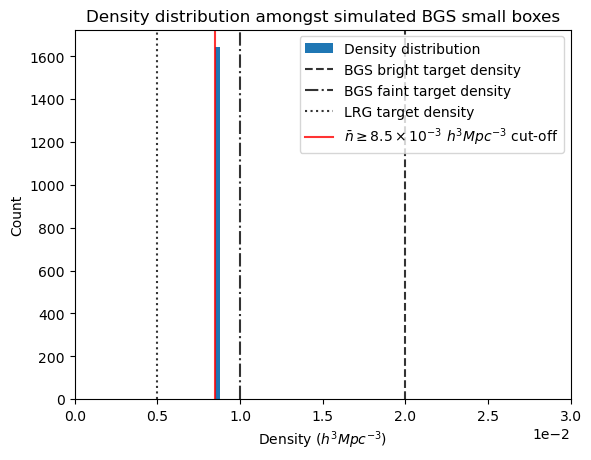

In [94]:
densities = get_densities(dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small')

bins = np.linspace(0, 0.03, 100)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.8, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS small boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

### 5.2- Two-point correlation function

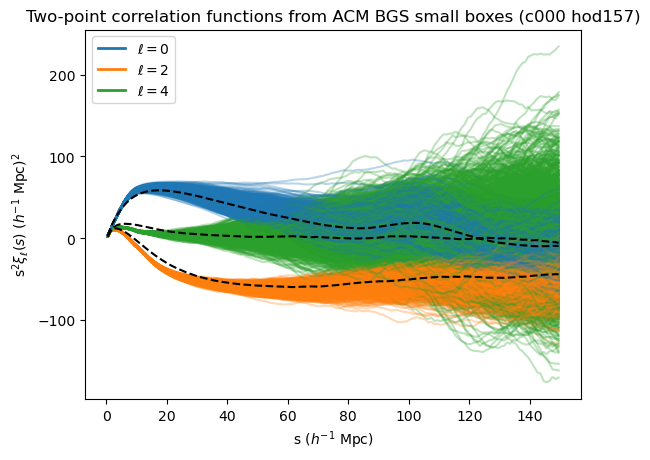

In [65]:
cfs = get_tpcf(dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small')

ells = [0, 2, 4]
for cf in cfs:
    s, poles = cf(ells=ells, return_sep=True)
    for i, p in enumerate(ells):
            plt.plot(s, poles[i]*s**2, alpha=0.3, c=f'C{i}')

handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=rf'$\ell={{{i*2}}}$') for i in range(3)
]
plt.legend(handles=handles)

plt.xlabel(r's ($h^{-1}$ Mpc)')
plt.ylabel(r's$^2 \xi_{\ell}(s)$ ($h^{-1}$ Mpc)$^2$')
plt.title('Two-point correlation functions from ACM BGS small boxes (c000 hod157)');

fns = sorted(sg_dir.glob('tpcf_los_*.npy'))
sg_cf = sum([TwoPointEstimator.load(fn).normalize() for fn in fns])

s, poles = sg_cf(ells=ells, return_sep=True)
for i, p in enumerate(ells):
    plt.plot(s, poles[i]*s**2, alpha=1.0, c=f'k', ls='--')
    
# plt.ylim(-100, 100);
# plt.xlim(0, 30);

### 5.3- Density split

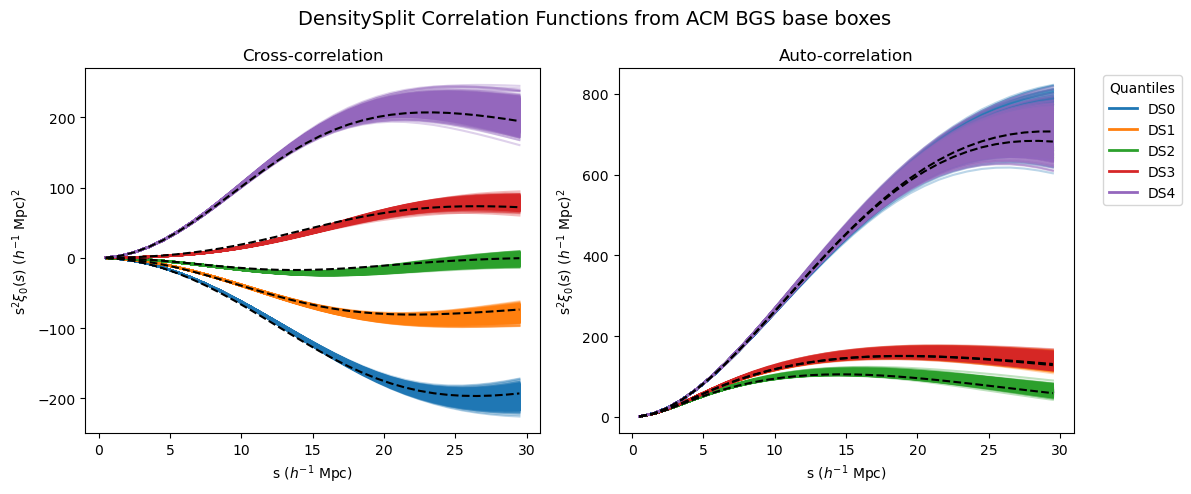

In [66]:
quantiles = [0, 1, 2, 3, 4] 
cc_cfs = get_ds_cf(stat_name='quantile_data_correlation', dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small', quantiles=quantiles)
ac_cfs = get_ds_cf(stat_name='quantile_correlation', dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small', quantiles=quantiles)

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)

ell = 0
for i, q in enumerate(quantiles):
    for cf in cc_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[0].plot(s, poles[0]*s**2, alpha=0.3, c=f'C{i}')
    for cf in ac_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[1].plot(s, poles[0]*s**2, alpha=0.3, c=f'C{i}')
        
handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=f'DS{q}') for i, q in enumerate(quantiles)
]
ax[1].legend(handles=handles, title='Quantiles', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[0].set_title('Cross-correlation')
ax[1].set_title('Auto-correlation')

for a in ax:
    a.set_xlabel(r's ($h^{-1}$ Mpc)')
    a.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')

fig.suptitle('DensitySplit Correlation Functions from ACM BGS base boxes', fontsize=14)
fig.tight_layout()

fn_list_cc = sorted(sg_dir.glob('quantile_data_correlation_los_*.npy'))
fn_list_ac = sorted(sg_dir.glob('quantile_correlation_los_*.npy'))
ccf = [sum([np.load(fn, allow_pickle=True)[q].normalize() for fn in fn_list_cc]) for q in quantiles]
acf = [sum([np.load(fn, allow_pickle=True)[q].normalize() for fn in fn_list_ac]) for q in quantiles]

for i, q in enumerate(quantiles):
    s, poles = ccf[i](ells=[ell], return_sep=True)
    ax[0].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

    s, poles = acf[i](ells=[ell], return_sep=True)
    ax[1].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

### Interractive vizualisations

In [ ]:
from matplotlib.widgets import Button, Slider
%matplotlib widget

ells = [0]

# Comment if the data is already loaded (to save time)
cfs = get_tpcf(dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small')

fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
fig.subplots_adjust(bottom=0.25)

s, poles = cfs[0](ells=ells, return_sep=True)
line = ax.plot(s, poles[0]*s**2, alpha=1.0, c='k')

fig.suptitle(f'TPCF Correlation for phase {phase_list[0]}', fontsize=14)
ax.set_xlabel(r's ($h^{-1}$ Mpc)')
ax.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')

handles = [
    plt.Line2D([0], [0], color=f'k', lw=2, label=fr'$\ell={{{ells[0]}}}$')
]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

slider_ax = fig.add_axes([0.25, 0.1, 0.65, 0.03])
phase_slider = Slider(
    ax=slider_ax,
    label='Phase Index',
    valmin=phase_list[0],
    valmax=phase_list[-1],
    valinit=phase_list[0],
    valstep=1,
    orientation='horizontal'
)

def plot_phase(idx: int):
    idx = int(idx)
    if idx not in phase_list:
        return
    idx = phase_list.index(idx)
    phase = phase_list[idx]
    s, poles = cfs[idx](ells=[0], return_sep=True)
    line[0].set_ydata(poles[0]*s**2)
    # for a in ax:
        # a.relim()
        # a.autoscale_view()
    fig.suptitle(f'TPCF Correlation for phase {phase}', fontsize=14)
    fig.canvas.draw_idle()

phase_slider.on_changed(plot_phase)

back_ax = fig.add_axes([0.25, 0.025, 0.1, 0.04])
back = Button(back_ax, '<', hovercolor='0.975')
back_func = lambda event: phase_slider.set_val(phase_list[phase_list.index(phase_slider.val) - 1])
back.on_clicked(back_func)
next_ax = fig.add_axes([0.35, 0.025, 0.1, 0.04])
next = Button(next_ax, '>', hovercolor='0.975')
next_func = lambda event: phase_slider.set_val(phase_list[phase_list.index(phase_slider.val) + 1])
next.on_clicked(next_func)
reset_ax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
reset = Button(reset_ax, 'Reset', hovercolor='0.975')
reset_func = lambda event: phase_slider.reset()
reset.on_clicked(reset_func);

In [13]:
plt.close('all')

In [ ]:
from matplotlib.widgets import Button, Slider
%matplotlib widget

quantiles = [0, 1, 2, 3, 4]
ells = [0]

# Comment if the data is already loaded (to save time)
cc_cfs = get_ds_cf(stat_name='quantile_data_correlation', dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small', quantiles=quantiles)
ac_cfs = get_ds_cf(stat_name='quantile_correlation', dir=measurements_dir, cosmologies=[0], phases=phase_list, seeds=[0], sim_type='small', quantiles=quantiles)

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)
fig.subplots_adjust(bottom=0.25)

cc_lines = []
ac_lines = []
for i, q in enumerate(quantiles):
    s, poles = cc_cfs[0][q](ells=ells, return_sep=True)
    line_cc, = ax[0].plot(s, poles[0]*s**2, alpha=1.0, c=f'C{i}', label=f'DS{q}')
    cc_lines.append(line_cc)
    
    s, poles = ac_cfs[0][q](ells=ells, return_sep=True)
    line_ac, = ax[1].plot(s, poles[0]*s**2, alpha=1.0, c=f'C{i}', label=f'DS{q}')
    ac_lines.append(line_ac)
fig.suptitle(f'DensitySplit Correlation for phase {phase_list[0]}', fontsize=14)
ax[0].set_title('Cross-correlation')
ax[1].set_title('Auto-correlation')
for a in ax:
    a.set_xlabel(r's ($h^{-1}$ Mpc)')
    a.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')

handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=f'DS{quantiles[i]}') for i in range(len(quantiles))
]
ax[1].legend(handles=handles, title='Quantiles', bbox_to_anchor=(1.05, 1), loc='upper left')

slider_ax = fig.add_axes([0.25, 0.1, 0.65, 0.03])
phase_slider = Slider(
    ax=slider_ax,
    label='Phase Index',
    valmin=phase_list[0],
    valmax=phase_list[-1],
    valinit=phase_list[0],
    valstep=1,
    orientation='horizontal'
)

def plot_phase(idx: int):
    idx = int(idx)
    if idx not in phase_list:
        return
    idx = phase_list.index(idx)
    phase = phase_list[idx]
    for i, q in enumerate(quantiles):
        s, poles = cc_cfs[idx][q](ells=[0], return_sep=True)
        cc_lines[i].set_ydata(poles[0]*s**2)
        
        s, poles = ac_cfs[idx][q](ells=[0], return_sep=True)
        ac_lines[i].set_ydata(poles[0]*s**2)
    # for a in ax:
        # a.relim()
        # a.autoscale_view()
    fig.suptitle(f'DensitySplit Correlation for phase {phase}', fontsize=14)
    fig.canvas.draw_idle()

phase_slider.on_changed(plot_phase)

back_ax = fig.add_axes([0.25, 0.025, 0.1, 0.04])
back = Button(back_ax, '<', hovercolor='0.975')
back_func = lambda event: phase_slider.set_val(phase_list[phase_list.index(phase_slider.val) - 1])
back.on_clicked(back_func)
next_ax = fig.add_axes([0.35, 0.025, 0.1, 0.04])
next = Button(next_ax, '>', hovercolor='0.975')
next_func = lambda event: phase_slider.set_val(phase_list[phase_list.index(phase_slider.val) + 1])
next.on_clicked(next_func)
reset_ax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
reset = Button(reset_ax, 'Reset', hovercolor='0.975')
reset_func = lambda event: phase_slider.reset()
reset.on_clicked(reset_func);

In [9]:
plt.close('all')

## 6- Compressed files